# Week 2 - Data Pipeline and Preprocessing

Goals:
1. Rebuild GTSRB metadata from official annotation CSV files.
2. Reconstruct fixed train/validation split from Week 1.
3. Implement optional ROI cropping.
4. Implement optional histogram equalization / CLAHE.
5. Build train/val/test PyTorch datasets and dataloaders.
6. Preview transformed batches and save metadata.


In [1]:
import os
import json
import random
import pathlib
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import GTSRB

from sklearn.model_selection import train_test_split

try:
    import cv2
except ImportError:
    !pip -q install opencv-python-headless
    import cv2

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
PROJECT_ROOT = pathlib.Path("/content/traffic-sign-classification")
DATA_ROOT = PROJECT_ROOT / "data"
REPORT_ROOT = PROJECT_ROOT / "reports" / "week2"
SPLIT_ROOT = PROJECT_ROOT / "artifacts" / "splits"
META_ROOT = PROJECT_ROOT / "artifacts" / "metadata"

for p in [DATA_ROOT, REPORT_ROOT, SPLIT_ROOT, META_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(DATA_ROOT)

/content/traffic-sign-classification
/content/traffic-sign-classification/data


In [5]:
train_idx = np.load(SPLIT_ROOT / "train_idx.npy")
val_idx = np.load(SPLIT_ROOT / "val_idx.npy")

print("Loaded train_idx:", train_idx.shape)
print("Loaded val_idx:", val_idx.shape)

Loaded train_idx: (23976,)
Loaded val_idx: (2664,)


In [6]:
tv_train = GTSRB(root=str(DATA_ROOT), split="train", download=True)
tv_test = GTSRB(root=str(DATA_ROOT), split="test", download=True)

print("Torchvision train size:", len(tv_train))
print("Torchvision test size:", len(tv_test))

100%|██████████| 187M/187M [00:15<00:00, 12.0MB/s]
100%|██████████| 89.0M/89.0M [00:05<00:00, 15.9MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 212kB/s]


Torchvision train size: 26640
Torchvision test size: 12630


In [7]:
tv_train_samples = tv_train._samples
tv_train_paths = np.array([str(pathlib.Path(p).resolve()) for p, y in tv_train_samples])

train_paths_set = set(tv_train_paths[train_idx])
val_paths_set = set(tv_train_paths[val_idx])

print("Train split paths:", len(train_paths_set))
print("Val split paths:", len(val_paths_set))
print("Overlap:", len(train_paths_set.intersection(val_paths_set)))

Train split paths: 23976
Val split paths: 2664
Overlap: 0


In [8]:
train_dir = DATA_ROOT / "gtsrb" / "GTSRB" / "Training"
csv_files = sorted(train_dir.glob("*/GT-*.csv"))

rows = []
for csv_file in csv_files:
    class_dir = csv_file.parent
    df = pd.read_csv(csv_file, sep=";")
    df["image_path"] = df["Filename"].apply(lambda x: str((class_dir / x).resolve()))
    rows.append(df)

train_df = pd.concat(rows, ignore_index=True)
train_df.head()

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,image_path
0,00000_00000.ppm,29,30,5,6,24,25,0,/content/traffic-sign-classification/data/gtsr...
1,00000_00001.ppm,30,30,5,5,25,25,0,/content/traffic-sign-classification/data/gtsr...
2,00000_00002.ppm,30,30,5,5,25,25,0,/content/traffic-sign-classification/data/gtsr...
3,00000_00003.ppm,31,31,5,5,26,26,0,/content/traffic-sign-classification/data/gtsr...
4,00000_00004.ppm,30,32,5,6,25,26,0,/content/traffic-sign-classification/data/gtsr...


In [12]:
train_df.columns = train_df.columns.str.strip()

rename_map = {
    "Filename": "filename",
    "Width": "width",
    "Height": "height",
    "ClassId": "label",

    "ROI.x1": "roi_x1",
    "ROI.y1": "roi_y1",
    "ROI.x2": "roi_x2",
    "ROI.y2": "roi_y2",

    "Roi.X1": "roi_x1",
    "Roi.Y1": "roi_y1",
    "Roi.X2": "roi_x2",
    "Roi.Y2": "roi_y2",
}

train_df = train_df.rename(columns=rename_map)

expected_cols = [
    "filename", "width", "height",
    "roi_x1", "roi_y1", "roi_x2", "roi_y2",
    "label", "image_path"
]

missing = [c for c in expected_cols if c not in train_df.columns]
if missing:
    raise ValueError(f"Missing columns after rename: {missing}\nActual columns: {train_df.columns.tolist()}")

print(train_df[expected_cols].head())
print("Rows:", len(train_df))
print("Unique labels:", train_df["label"].nunique())

          filename  width  height  roi_x1  roi_y1  roi_x2  roi_y2  label  \
0  00000_00000.ppm     29      30       5       6      24      25      0   
1  00000_00001.ppm     30      30       5       5      25      25      0   
2  00000_00002.ppm     30      30       5       5      25      25      0   
3  00000_00003.ppm     31      31       5       5      26      26      0   
4  00000_00004.ppm     30      32       5       6      25      26      0   

                                          image_path  
0  /content/traffic-sign-classification/data/gtsr...  
1  /content/traffic-sign-classification/data/gtsr...  
2  /content/traffic-sign-classification/data/gtsr...  
3  /content/traffic-sign-classification/data/gtsr...  
4  /content/traffic-sign-classification/data/gtsr...  
Rows: 26640
Unique labels: 43


In [13]:
def assign_split(path):
    if path in train_paths_set:
        return "train"
    elif path in val_paths_set:
        return "val"
    else:
        return "unassigned"

train_df["split"] = train_df["image_path"].apply(assign_split)
train_df["split"].value_counts()

,count
split,
train,23976
val,2664


In [14]:
unassigned = train_df[train_df["split"] == "unassigned"]
print("Unassigned rows:", len(unassigned))

assert len(unassigned) == 0, "Some training images were not matched to Week 1 split."
assert len(train_df[train_df["split"] == "train"]) == len(train_idx)
assert len(train_df[train_df["split"] == "val"]) == len(val_idx)

print("Split mapping looks correct.")

Unassigned rows: 0
Split mapping looks correct.


In [15]:
gtsrb_root = DATA_ROOT / "gtsrb"
test_csv = gtsrb_root / "GT-final_test.csv"
test_img_dir = gtsrb_root / "GTSRB" / "Final_Test" / "Images"

test_df = pd.read_csv(test_csv, sep=";")
test_df["image_path"] = test_df["Filename"].apply(lambda x: str((test_img_dir / x).resolve()))
test_df = test_df.rename(columns={
    "Width": "width",
    "Height": "height",
    "ROI.x1": "roi_x1",
    "ROI.y1": "roi_y1",
    "ROI.x2": "roi_x2",
    "ROI.y2": "roi_y2",
    "ClassId": "label",
    "Filename": "filename"
})
test_df["split"] = "test"

print(test_df.head())
print("Test rows:", len(test_df))

    filename  width  height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  label  \
0  00000.ppm     53      54       6       5      48      49     16   
1  00001.ppm     42      45       5       5      36      40      1   
2  00002.ppm     48      52       6       6      43      47     38   
3  00003.ppm     27      29       5       5      22      24     33   
4  00004.ppm     60      57       5       5      55      52     11   

                                          image_path split  
0  /content/traffic-sign-classification/data/gtsr...  test  
1  /content/traffic-sign-classification/data/gtsr...  test  
2  /content/traffic-sign-classification/data/gtsr...  test  
3  /content/traffic-sign-classification/data/gtsr...  test  
4  /content/traffic-sign-classification/data/gtsr...  test  
Test rows: 12630


In [16]:
train_df.to_csv(META_ROOT / "train_metadata_full.csv", index=False)
test_df.to_csv(META_ROOT / "test_metadata_full.csv", index=False)

print("Saved metadata CSVs.")

Saved metadata CSVs.


In [17]:
def crop_roi(pil_img, row, pad_ratio=0.08):
    w, h = pil_img.size
    x1, y1, x2, y2 = int(row["roi_x1"]), int(row["roi_y1"]), int(row["roi_x2"]), int(row["roi_y2"])

    bw = x2 - x1
    bh = y2 - y1
    pad_x = int(bw * pad_ratio)
    pad_y = int(bh * pad_ratio)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)

    return pil_img.crop((x1, y1, x2, y2))

In [18]:
def pil_to_cv_rgb(img):
    return np.array(img)

def cv_rgb_to_pil(img):
    return Image.fromarray(img.astype(np.uint8))

def equalize_rgb(img_pil):
    img = pil_to_cv_rgb(img_pil)
    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])
    out = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)
    return cv_rgb_to_pil(out)

def clahe_rgb(img_pil, clip_limit=2.0, tile_grid_size=(8, 8)):
    img = pil_to_cv_rgb(img_pil)
    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    ycrcb[:, :, 0] = clahe.apply(ycrcb[:, :, 0])
    out = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)
    return cv_rgb_to_pil(out)

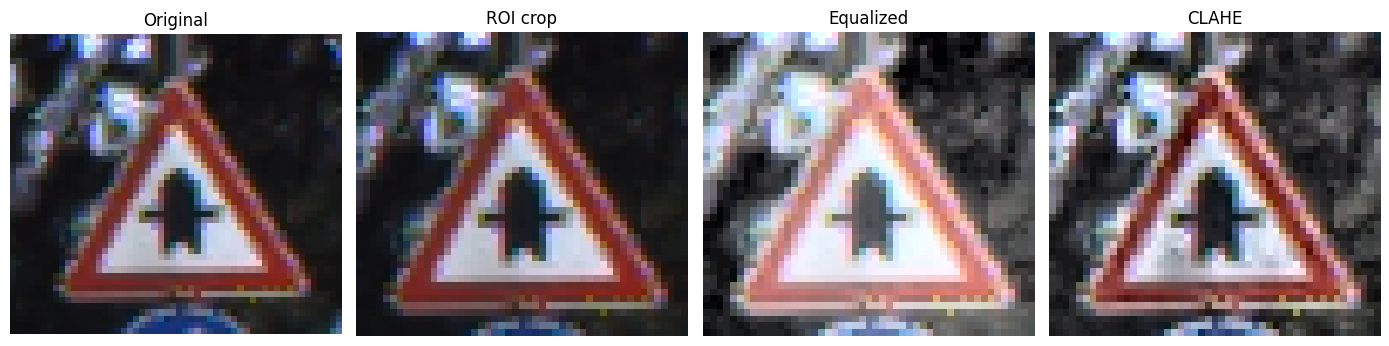

In [19]:
sample_row = train_df.sample(1, random_state=SEED).iloc[0]
img = Image.open(sample_row["image_path"]).convert("RGB")

img_crop = crop_roi(img, sample_row)
img_eq = equalize_rgb(img_crop)
img_clahe = clahe_rgb(img_crop)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(img_crop)
axes[1].set_title("ROI crop")
axes[2].imshow(img_eq)
axes[2].set_title("Equalized")
axes[3].imshow(img_clahe)
axes[3].set_title("CLAHE")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.savefig(REPORT_ROOT / "preprocessing_preview.png", dpi=200)
plt.show()

In [20]:
@dataclass
class DataConfig:
    image_size: int = 64
    use_roi_crop: bool = True
    preprocessing: str = "none"   # "none", "equalize", "clahe"
    pad_ratio: float = 0.08

In [21]:
class GTSRBCustomDataset(Dataset):
    def __init__(self, df, transform=None, use_roi_crop=False, preprocessing="none", pad_ratio=0.08):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.use_roi_crop = use_roi_crop
        self.preprocessing = preprocessing
        self.pad_ratio = pad_ratio

    def __len__(self):
        return len(self.df)

    def _preprocess(self, img, row):
        if self.use_roi_crop:
            img = crop_roi(img, row, pad_ratio=self.pad_ratio)

        if self.preprocessing == "equalize":
            img = equalize_rgb(img)
        elif self.preprocessing == "clahe":
            img = clahe_rgb(img)

        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self._preprocess(img, row)

        if self.transform is not None:
            img = self.transform(img)

        label = int(row["label"])
        return img, label

In [22]:
train_meta = train_df[train_df["split"] == "train"].reset_index(drop=True)
val_meta = train_df[train_df["split"] == "val"].reset_index(drop=True)

print("Train rows:", len(train_meta))
print("Val rows:", len(val_meta))
print("Test rows:", len(test_df))

Train rows: 23976
Val rows: 2664
Test rows: 12630


In [23]:
IMG_SIZE = 64

train_transform_preview = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.10, 0.10), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])

eval_transform_preview = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [24]:
preview_cfg = DataConfig(
    image_size=64,
    use_roi_crop=True,
    preprocessing="clahe",
    pad_ratio=0.08
)

preview_train_ds = GTSRBCustomDataset(
    train_meta,
    transform=train_transform_preview,
    use_roi_crop=preview_cfg.use_roi_crop,
    preprocessing=preview_cfg.preprocessing,
    pad_ratio=preview_cfg.pad_ratio
)

preview_val_ds = GTSRBCustomDataset(
    val_meta,
    transform=eval_transform_preview,
    use_roi_crop=preview_cfg.use_roi_crop,
    preprocessing=preview_cfg.preprocessing,
    pad_ratio=preview_cfg.pad_ratio
)

len(preview_train_ds), len(preview_val_ds)

(23976, 2664)

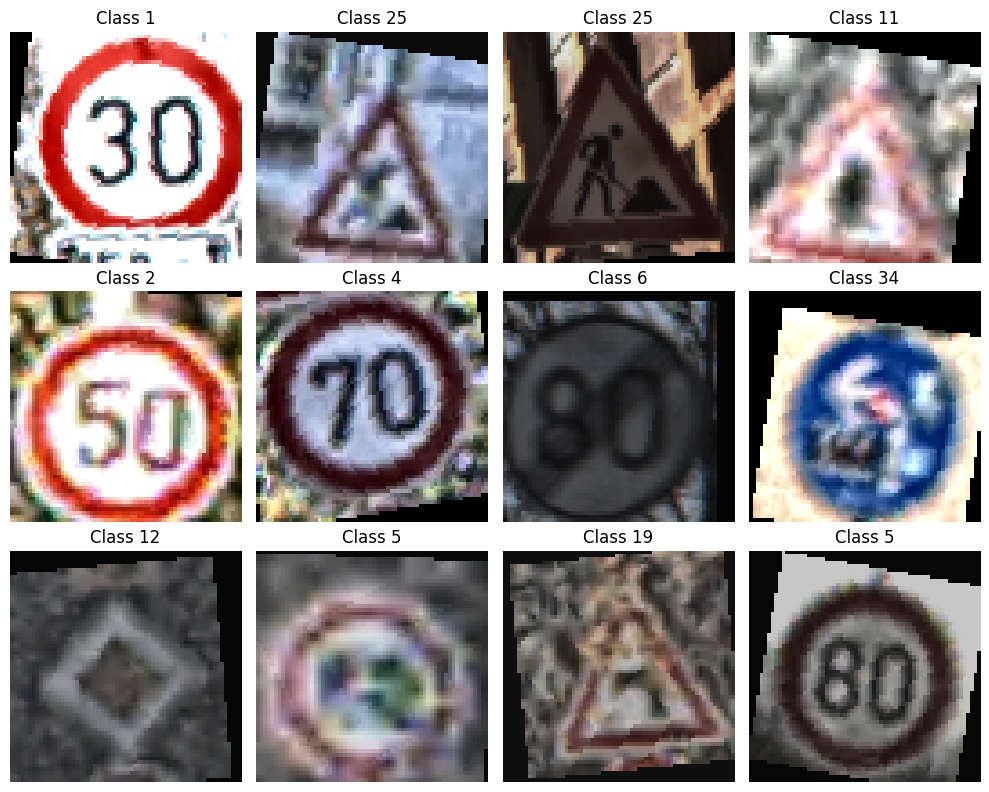

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
indices = np.random.choice(len(preview_train_ds), size=12, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    x, y = preview_train_ds[idx]
    ax.imshow(np.transpose(x.numpy(), (1, 2, 0)).clip(0, 1))
    ax.set_title(f"Class {y}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(REPORT_ROOT / "train_transform_preview.png", dpi=200)
plt.show()

In [26]:
stats_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

stats_ds = GTSRBCustomDataset(
    train_meta,
    transform=stats_transform,
    use_roi_crop=True,
    preprocessing="clahe",
    pad_ratio=0.08
)

stats_loader = DataLoader(stats_ds, batch_size=128, shuffle=False, num_workers=2)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_batches = 0

for x, _ in stats_loader:
    channel_sum += x.mean(dim=[0, 2, 3])
    channel_sq_sum += (x ** 2).mean(dim=[0, 2, 3])
    num_batches += 1

mean = channel_sum / num_batches
std = (channel_sq_sum / num_batches - mean ** 2).sqrt()

print("Mean:", mean)
print("Std :", std)

Mean: tensor([0.4808, 0.4455, 0.4587])
Std : tensor([0.2539, 0.2469, 0.2560])


In [27]:
MEAN = mean.tolist()
STD = std.tolist()

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.10, 0.10), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [28]:
final_cfg = DataConfig(
    image_size=64,
    use_roi_crop=True,
    preprocessing="clahe",   # can switch later: "none", "equalize", "clahe"
    pad_ratio=0.08
)

train_ds = GTSRBCustomDataset(
    train_meta,
    transform=train_transform,
    use_roi_crop=final_cfg.use_roi_crop,
    preprocessing=final_cfg.preprocessing,
    pad_ratio=final_cfg.pad_ratio
)

val_ds = GTSRBCustomDataset(
    val_meta,
    transform=eval_transform,
    use_roi_crop=final_cfg.use_roi_crop,
    preprocessing=final_cfg.preprocessing,
    pad_ratio=final_cfg.pad_ratio
)

test_ds = GTSRBCustomDataset(
    test_df,
    transform=eval_transform,
    use_roi_crop=final_cfg.use_roi_crop,
    preprocessing=final_cfg.preprocessing,
    pad_ratio=final_cfg.pad_ratio
)

len(train_ds), len(val_ds), len(test_ds)

(23976, 2664, 12630)

In [29]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 188
Val batches: 21
Test batches: 99


In [30]:
x_batch, y_batch = next(iter(train_loader))

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("dtype:", x_batch.dtype)
print("labels sample:", y_batch[:10].tolist())

x_batch shape: torch.Size([128, 3, 64, 64])
y_batch shape: torch.Size([128])
dtype: torch.float32
labels sample: [2, 12, 25, 25, 27, 18, 7, 12, 13, 3]


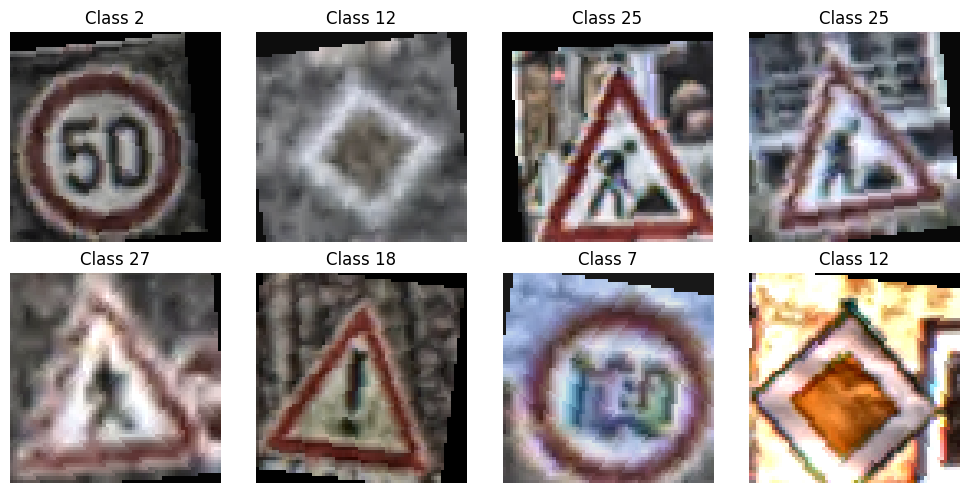

In [31]:
def denormalize(x, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return x * std + mean

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(x_batch[i].cpu(), MEAN, STD).permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(img)
    ax.set_title(f"Class {int(y_batch[i])}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(REPORT_ROOT / "normalized_batch_preview.png", dpi=200)
plt.show()

In [32]:
pipeline_config = {
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "use_roi_crop": final_cfg.use_roi_crop,
    "preprocessing": final_cfg.preprocessing,
    "pad_ratio": final_cfg.pad_ratio,
    "mean": MEAN,
    "std": STD
}

with open(META_ROOT / "week2_pipeline_config.json", "w") as f:
    json.dump(pipeline_config, f, indent=2)

print(json.dumps(pipeline_config, indent=2))

{
  "seed": 42,
  "image_size": 64,
  "batch_size": 128,
  "use_roi_crop": true,
  "preprocessing": "clahe",
  "pad_ratio": 0.08,
  "mean": [
    0.48077961802482605,
    0.4455212652683258,
    0.45868155360221863
  ],
  "std": [
    0.2539152204990387,
    0.2469169795513153,
    0.25597625970840454
  ]
}


In [33]:
train_counts = train_meta["label"].value_counts().sort_index()
val_counts = val_meta["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

split_counts_df = pd.DataFrame({
    "ClassId": sorted(train_counts.index),
    "TrainCount": train_counts.values,
    "ValCount": val_counts.reindex(train_counts.index, fill_value=0).values,
    "TestCount": test_counts.reindex(train_counts.index, fill_value=0).values
})

split_counts_df.to_csv(REPORT_ROOT / "split_class_counts.csv", index=False)
split_counts_df.head()

,ClassId,TrainCount,ValCount,TestCount
0,0,135,15,60
1,1,1350,150,720
2,2,1350,150,750
3,3,864,96,450
4,4,1188,132,660


In [34]:
summary = pd.DataFrame([{
    "train_rows": len(train_meta),
    "val_rows": len(val_meta),
    "test_rows": len(test_df),
    "image_size": IMG_SIZE,
    "use_roi_crop": final_cfg.use_roi_crop,
    "preprocessing": final_cfg.preprocessing,
    "batch_size": BATCH_SIZE
}])

summary.to_csv(REPORT_ROOT / "week2_summary.csv", index=False)
summary

,train_rows,val_rows,test_rows,image_size,use_roi_crop,preprocessing,batch_size
0,23976,2664,12630,64,True,clahe,128
